# Curva ROC-AUC e Tratamento de Datasets Desbalanceados

# Curva ROC e AUC

## Matriz de confusão: a base de tudo

Em um problema de classificação binária com rótulos **positivo (1)** e **negativo (0)**:

| | Previsto = 1 | Previsto = 0 |
|---|---|---|
| **Real = 1** | TP (Verdadeiro Positivo) | FN (Falso Negativo) |
| **Real = 0** | FP (Falso Positivo) | TN (Verdadeiro Negativo) |

A partir dela definimos duas taxas fundamentais:

$$\text{TPR} = \text{Recall} = \frac{TP}{TP + FN} = \frac{TP}{P}$$

$$\text{FPR} = \frac{FP}{FP + TN} = \frac{FP}{N}$$

- **TPR** (*True Positive Rate*): dos pacientes **realmente doentes**, quantos o modelo pegou?
- **FPR** (*False Positive Rate*): dos pacientes **realmente saudáveis**, quantos o modelo classificou erradamente como doentes?

## De onde surge a curva?

Um classificador probabilístico (regressão logística, rede neural com softmax, random forest, etc.) não devolve diretamente 0 ou 1 — ele devolve uma **probabilidade** $\hat{p} \in [0, 1]$. Para decidir a classe, aplicamos um **threshold** $t$:

$$\hat{y} = \begin{cases} 1 & \text{se } \hat{p} \geq t \\ 0 & \text{caso contrário}\end{cases}$$

Cada escolha de $t$ gera uma matriz de confusão diferente, e portanto um par $(\text{FPR}, \text{TPR})$ diferente. **A curva ROC é o conjunto de todos testes nesses pontos** quando variamos $t$ de 1 até 0.

## O que é AUC?

**AUC** (*Area Under the Curve*) é a área sob a curva ROC, entre 0 e 1:

- **AUC = 1.0** → classificador perfeito
- **AUC = 0.5** → classificador aleatório (curva é a diagonal)
- **AUC < 0.5** → pior que aleatório (basta inverter as previsões!)

Interpretação probabilística elegante: **AUC é a probabilidade de que, sorteando um exemplo positivo e um negativo aleatoriamente, o modelo atribua probabilidade maior ao positivo do que ao negativo.**

## Exemplo numérico

Imagine que treinamos um modelo para classificar tumores como **malignos (1)** ou **benignos (0)** em 10 pacientes. O modelo devolveu as seguintes probabilidades, **sobre o conjunto de testes**:

| Paciente | Real (y) | Score ($\hat{p}$) |
|:---:|:---:|:---:|
| P01 | 1 | 0.95 |
| P02 | 1 | 0.86 |
| P03 | 0 | 0.80 |
| P04 | 1 | 0.72 |
| P05 | 1 | 0.65 |
| P06 | 0 | 0.55 |
| P07 | 0 | 0.43 |
| P08 | 1 | 0.40 |
| P09 | 0 | 0.25 |
| P10 | 0 | 0.10 |

Temos **P = 5** positivos reais e **N = 5** negativos reais.

### Procedimento

1. Ordenar os pacientes por score decrescente (já está).
2. Para cada threshold possível, classificar todos como 1 ou 0 e contar TP, FP, FN, TN.
3. Calcular TPR = TP/P e FPR = FP/N.
4. Plotar os pontos (FPR, TPR) e ligá-los.

Vamos calcular alguns pontos manualmente:

**Threshold t = 0.86:** Classifica P01 e P02 como positivos.
TP = 2, FP = 0, FN = 3, TN = 5 → TPR = 2/5 = 0.40, FPR = 0/5 = 0.00

**Threshold t = 0.80:** Adiciona P03 (negativo) aos positivos previstos.
TP = 2, FP = 1, FN = 3, TN = 4 → TPR = 0.40, FPR = 0.20

**Threshold t = 0.65:** Adiciona P04 e P05 (positivos).
TP = 4, FP = 1, FN = 1, TN = 4 → TPR = 0.80, FPR = 0.20

Note o padrão: cada vez que o próximo score é de um **positivo**, a curva **sobe**; se é de um **negativo**, a curva **vai para a direita**.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_true  = np.array([1, 1, 0, 1, 1, 0, 0, 1, 0, 0])
y_score = np.array([0.95, 0.86, 0.80, 0.72, 0.65, 0.55, 0.43, 0.40, 0.25, 0.10])

P = y_true.sum()
N = len(y_true) - P
print(f"Positivos reais (P) = {P}  |  Negativos reais (N) = {N}\n")

# Tabela completa para cada threshold
thresholds = sorted(set(y_score.tolist()) | {1.01}, reverse=True)
print(f"{'thr':>6} | {'TP':>3} {'FP':>3} {'FN':>3} {'TN':>3} | {'TPR':>6} {'FPR':>6}")
print("-" * 55)
for thr in thresholds:
    y_pred = (y_score >= thr).astype(int)
    TP = int(((y_pred == 1) & (y_true == 1)).sum())
    FP = int(((y_pred == 1) & (y_true == 0)).sum())
    FN = int(((y_pred == 0) & (y_true == 1)).sum())
    TN = int(((y_pred == 0) & (y_true == 0)).sum())
    print(f"{thr:6.2f} | {TP:3d} {FP:3d} {FN:3d} {TN:3d} | {TP/P:6.3f} {FP/N:6.3f}")

Positivos reais (P) = 5  |  Negativos reais (N) = 5

   thr |  TP  FP  FN  TN |    TPR    FPR
-------------------------------------------------------
  1.01 |   0   0   5   5 |  0.000  0.000
  0.95 |   1   0   4   5 |  0.200  0.000
  0.86 |   2   0   3   5 |  0.400  0.000
  0.80 |   2   1   3   4 |  0.400  0.200
  0.72 |   3   1   2   4 |  0.600  0.200
  0.65 |   4   1   1   4 |  0.800  0.200
  0.55 |   4   2   1   3 |  0.800  0.400
  0.43 |   4   3   1   2 |  0.800  0.600
  0.40 |   5   3   0   2 |  1.000  0.600
  0.25 |   5   4   0   1 |  1.000  0.800
  0.10 |   5   5   0   0 |  1.000  1.000


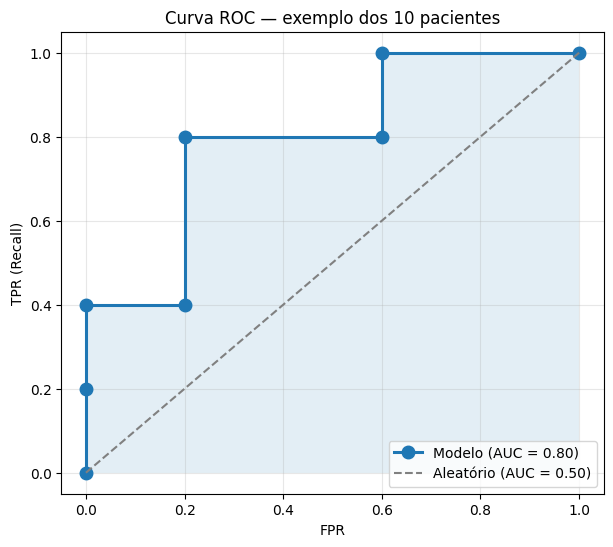


AUC = 0.8000


In [ ]:
# Plotando a ROC
fpr, tpr, thr = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, 'o-', lw=2.2, markersize=9, label=f'Modelo (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Aleatório (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.12)
plt.xlabel('FPR'); plt.ylabel('TPR (Recall)')
plt.title('Curva ROC — exemplo dos 10 pacientes')
plt.grid(alpha=0.3); plt.legend(loc='lower right')
plt.show()

print(f"\nAUC = {auc:.4f}")

## Cálculo da AUC pela regra do trapézio

A área sob a curva em degraus pode ser calculada somando as áreas de trapézios formados entre pontos consecutivos $(FPR_i, TPR_i)$:

$$AUC = \sum_{i=1}^{n} \frac{(FPR_i - FPR_{i-1}) \cdot (TPR_i + TPR_{i-1})}{2}$$

Para esse exemplo, o cálculo manual dá **AUC = 0.80**, o que significa que em 80% dos pares (positivo, negativo) sorteados aleatoriamente, o modelo dá score mais alto para o positivo. Nada mal!

In [ ]:
# Cálculo manual da AUC pela regra do trapézio — batendo com sklearn
auc_manual = np.trapezoid(tpr, fpr)
print(f"AUC (trapézio manual): {auc_manual:.4f}")
print(f"AUC (scikit-learn):    {roc_auc_score(y_true, y_score):.4f}")

AUC (trapézio manual): 0.8000
AUC (scikit-learn):    0.8000


## Intuição visual: como a AUC reflete a separação das classes

Quanto mais separadas as distribuições de score das classes positiva e negativa, maior a AUC. Simulação:

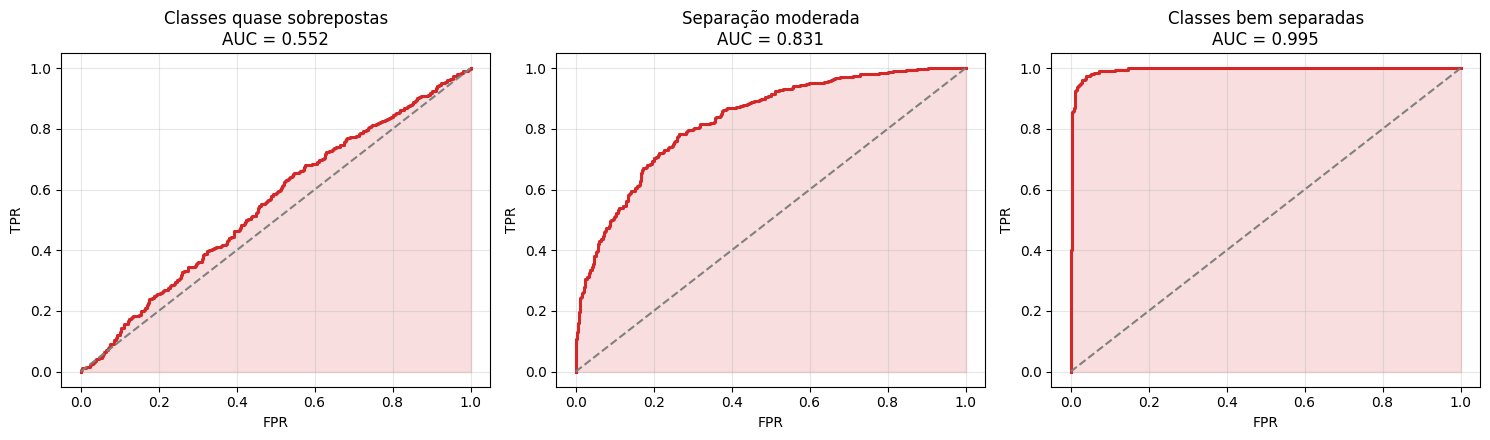

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
np.random.seed(1)
n = 500
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (sep, titulo) in zip(axes, [(0.2, 'Classes quase sobrepostas'),
                                     (1.5, 'Separação moderada'),
                                     (3.5, 'Classes bem separadas')]):
    neg = np.random.normal(0, 1, n)
    pos = np.random.normal(sep, 1, n)
    y = np.r_[np.zeros(n), np.ones(n)]
    s = np.r_[neg, pos]
    fpr, tpr, _ = roc_curve(y, s)
    a = roc_auc_score(y, s)
    ax.plot(fpr, tpr, lw=2.2, color='#d62728')
    ax.plot([0, 1], [0, 1], '--', color='gray')
    ax.fill_between(fpr, tpr, alpha=0.15, color='#d62728')
    ax.set_title(f'{titulo}\nAUC = {a:.3f}')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Datasets desbalanceados

## Por que isso é um problema?

Considere um dataset de **detecção de fraude em cartão de crédito**, onde apenas 2% das transações são fraudulentas. Um modelo ingênuo que sempre prediz "não é fraude" atinge **98% de accuracy** — e é completamente inútil, porque nunca detecta uma fraude.

Em problemas desbalanceados (fraude, doenças raras, churn, detecção de falhas), a classe minoritária é justamente a que importa. Precisamos de:

- **Métricas apropriadas**: AUC, Recall, Precision, F1, PR-AUC — não accuracy.
- **Técnicas de balanceamento**: alterar a distribuição no treino, ou ensinar o modelo a "prestar mais atenção" na minoria.

## Simulação: detecção de fraude

Vamos criar um dataset sintético com 10.000 transações e apenas **~2% de fraudes**.

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve,
                              classification_report, confusion_matrix)

X, y = make_classification(
    n_samples=10_000, n_features=10, n_informative=5, n_redundant=2,
    weights=[0.98, 0.02], flip_y=0.01, random_state=42
)
print(f"Total de amostras: {len(y)}")
print(f"Não-fraude (0): {(y == 0).sum()}  ({(y == 0).mean() * 100:.2f}%)")
print(f"Fraude      (1): {(y == 1).sum()}  ({(y == 1).mean() * 100:.2f}%)")

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
print(f"\nTreino: {np.bincount(y_tr)}  | Teste: {np.bincount(y_te)}")

Total de amostras: 10000
Não-fraude (0): 9754  (97.54%)
Fraude      (1): 246  (2.46%)

Treino: [6828  172]  | Teste: [2926   74]


### O baseline ingênuo

> "Se eu te pagar R$ 1.000 para construir um detector de fraude com 99% de acurácia, você aceita? Tenho um modelo de 1 linha que faz isso agora."
>
>   ```python
>    pythondef detectar_fraude(transacao):
>        return "não é fraude"
>    ```
> Esse modelo acerta 98% das transações no nosso dataset. Ele é útil? Não detecta uma única fraude. E no entanto, pela accuracy, é "excelente"."

Um **baseline ingênuo** é um modelo de referência propositalmente simples, que serve como piso mínimo contra o qual qualquer modelo sofisticado deve ser comparado. Se o seu XGBoost com $200$ features não bate o baseline ingênuo, ele não está aprendendo nada — está só imitando o desequilíbrio dos dados.

No nosso caso de fraude (98% não-fraude, 2% fraude), o majority baseline **sempre prevê "não é fraude"**.

|              | Previsto | Previsto | | |
|--|--|--|--|--|
|  | | não-fraude | fraude |  |
| Real |  não-fraude |   2926  |     0        | TN = 2926 |
| Real | fraude      |    74   |     0        | FN = 74 |

- Accuracy = (TN + TP) / total = 2926 / 3000 = 97,5% ✅ "ótimo!"
- Recall da classe fraude = TP / (TP + FN) = 0 / 74 = 0% ❌
- Precision da classe fraude = TP / (TP + FP) = 0 / 0 → indefinido
- F1 = 0

> O modelo sabe ranquear as transações (AUC = 0.72 comprova), mas **não sabe decidir** com o threshold padrão. Balanceamento conserta essa decisão.

**Conclusões explícitas:**

- **Toda métrica precisa de referência.** Reportar "meu modelo tem 98% de *accuracy*" sem comparar com o baseline ingênuo é mentir por omissão. Relate sempre: "*Accuracy* do meu modelo = 98%, *accuracy* do baseline majoritário = 98%, ganho = 0%."

- **A escolha da métrica define o problema.** Se você otimizar *accuracy* num dataset desbalanceado, o gradiente descendente vai literalmente convergir para o baseline ingênuo, porque ele é a solução ótima para essa função de perda. É por isso que mudamos de métrica (AUC, F1, PR-AUC) ou mudamos os dados (SMOTE et al.) ou mudamos a loss (class_weight).

In [ ]:
modelo = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
pred = modelo.predict(X_te)
proba = modelo.predict_proba(X_te)[:, 1]

print("Matriz de confusão:")
print(confusion_matrix(y_te, pred))
print("\n", classification_report(y_te, pred, digits=3))
print(f"Accuracy: {(pred == y_te).mean():.4f}")
print(f"AUC:      {roc_auc_score(y_te, proba):.4f}")

Matriz de confusão:
[[2925    1]
 [  73    1]]

               precision    recall  f1-score   support

           0      0.976     1.000     0.988      2926
           1      0.500     0.014     0.026        74

    accuracy                          0.975      3000
   macro avg      0.738     0.507     0.507      3000
weighted avg      0.964     0.975     0.964      3000

Accuracy: 0.9753
AUC:      0.7183


Veja o paradoxo: a **accuracy fica altíssima (~98%)**, mas o **recall da classe 1 é próximo de zero** — o modelo quase não identifica fraudes. Esse é exatamente o problema que as técnicas a seguir resolvem.

Estudar: [`DummyClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html).

## Panorama das técnicas

As abordagens se dividem em três grandes grupos:

### A) Nível dos dados — alterar a distribuição do treino

| Técnica | Ideia | Prós | Contras |
|---|---|---|---|
| **Random OverSampling (ROS)** | Duplica amostras da classe minoritária | Simples, não perde dados | Risco de overfitting |
| **Random UnderSampling (RUS)** | Descarta amostras da majoritária | Rápido, treino menor | Perde informação |
| **SMOTE** | Cria exemplos **sintéticos** por interpolação entre vizinhos k-NN da minoritária | Aumenta dados sem duplicar | Pode gerar ruído em fronteiras |
| **ADASYN** | Variante do SMOTE que foca em amostras difíceis | Bom em fronteiras | Mais sensível a ruído |
| **Borderline-SMOTE** | SMOTE aplicado só em amostras próximas da fronteira | Foco onde importa | Mais complexo |
| **Tomek Links** | Remove pares de classes opostas muito próximas | Limpa fronteira | Undersampling leve |
| **ENN** (Edited Nearest Neighbors) | Remove amostras majoritárias cujos vizinhos discordam | Limpa ruído | Undersampling leve |
| **SMOTE + ENN** / **SMOTE + Tomek** | Combinados: primeiro sintetiza, depois limpa | Geralmente o melhor | Custo computacional |



### B) Nível do algoritmo — alterar o modelo

| Técnica | Ideia |
|---|---|
| **Class weighting** (`class_weight='balanced'`) | Penaliza mais os erros na classe minoritária na função de perda |
| **Cost-sensitive learning** | Generalização: matriz de custo específica por tipo de erro |
| **Ensembles especializados** | BalancedRandomForest, EasyEnsemble, RUSBoost |



### C) Nível da decisão — alterar o threshold

Em vez de usar 0.5, encontre o melhor threshold na ROC ou na curva Precision-Recall para o seu problema (ex.: o ponto que maximiza F1, ou que atinge o recall mínimo exigido pelo negócio).


## SMOTE em detalhe

O **SMOTE** (*Synthetic Minority Over-sampling Technique*, Chawla et al., 2002) não duplica — ele cria **exemplos novos** por interpolação linear:

1. Para cada amostra $x_i$ da classe minoritária, encontre seus **k vizinhos mais próximos** (geralmente k=5) dentro da própria classe.
2. Sorteie um vizinho $x_{zi}$.
3. Gere um exemplo sintético: $x_{novo} = x_i + \lambda \cdot (x_{zi} - x_i)$, com $\lambda \sim U(0, 1)$.
4. Repita até igualar as classes.

Cuidado importantíssimo: **SMOTE deve ser aplicado APENAS no conjunto de treino**, nunca no teste. Caso contrário, há vazamento de informação.

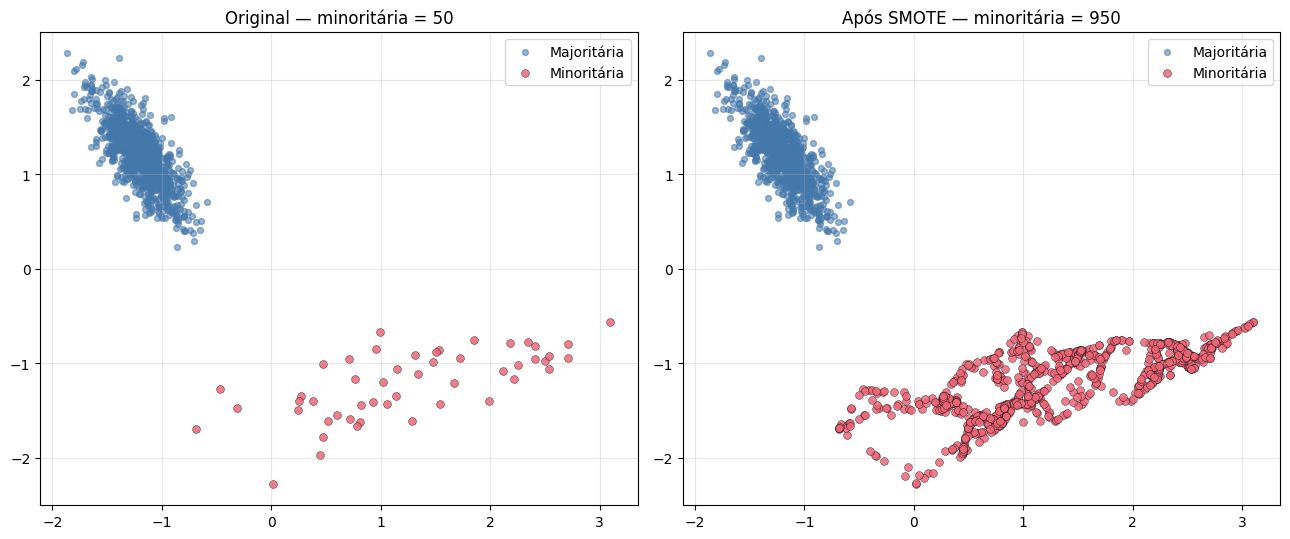

In [ ]:
# Visualização 2D do efeito do SMOTE
from imblearn.over_sampling import SMOTE

Xv, yv = make_classification(n_samples=1000, n_features=2, n_informative=2,
                              n_redundant=0, n_clusters_per_class=1,
                              weights=[0.95, 0.05], flip_y=0,
                              class_sep=1.2, random_state=7)
Xs, ys = SMOTE(random_state=7).fit_resample(Xv, yv)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, (X_, y_, tit) in zip(axes,
        [(Xv, yv, f'Original — minoritária = {(yv==1).sum()}'),
         (Xs, ys, f'Após SMOTE — minoritária = {(ys==1).sum()}')]):
    ax.scatter(X_[y_==0, 0], X_[y_==0, 1], c='#4477aa', s=18, alpha=0.55, label='Majoritária')
    ax.scatter(X_[y_==1, 0], X_[y_==1, 1], c='#ee6677', s=32, alpha=0.85,
               label='Minoritária', edgecolor='black', linewidth=0.3)
    ax.set_title(tit); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## Comparação empírica das técnicas

Vamos treinar a mesma regressão logística aplicando cada técnica ao conjunto de treino e comparar o desempenho no mesmo conjunto de teste (intocado).

In [ ]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

resultados = []

def avaliar(nome, X_train, y_train, X_test, y_test, **kwargs):
    m = LogisticRegression(max_iter=1000, **kwargs).fit(X_train, y_train)
    proba = m.predict_proba(X_test)[:, 1]
    pred = m.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    auc = roc_auc_score(y_test, proba)
    recall = tp / (tp + fn) if (tp + fn) else 0
    precision = tp / (tp + fp) if (tp + fp) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    resultados.append({'tecnica': nome, 'AUC': auc, 'Recall': recall,
                       'Precision': precision, 'F1': f1, 'FN': fn, 'FP': fp})
    return m, proba

# 1) Baseline
avaliar("Baseline (sem tratamento)", X_tr, y_tr, X_te, y_te)

# 2) class_weight
avaliar("class_weight=balanced", X_tr, y_tr, X_te, y_te, class_weight='balanced')

# 3) Random OverSampling
Xr, yr = RandomOverSampler(random_state=42).fit_resample(X_tr, y_tr)
avaliar("Random OverSampling", Xr, yr, X_te, y_te)

# 4) Random UnderSampling
Xu, yu = RandomUnderSampler(random_state=42).fit_resample(X_tr, y_tr)
avaliar("Random UnderSampling", Xu, yu, X_te, y_te)

# 5) SMOTE
Xs, ys = SMOTE(random_state=42).fit_resample(X_tr, y_tr)
avaliar("SMOTE", Xs, ys, X_te, y_te)

# 6) SMOTE + ENN (combinado)
Xc, yc = SMOTEENN(random_state=42).fit_resample(X_tr, y_tr)
avaliar("SMOTE + ENN", Xc, yc, X_te, y_te)

import pandas as pd
df = pd.DataFrame(resultados).round(4)
print(df.to_string(index=False))

                  tecnica    AUC  Recall  Precision     F1  FN  FP
Baseline (sem tratamento) 0.7183  0.0135     0.5000 0.0263  73   1
    class_weight=balanced 0.7487  0.6892     0.0618 0.1135  23 774
      Random OverSampling 0.7479  0.6757     0.0600 0.1103  24 783
     Random UnderSampling 0.7489  0.6622     0.0578 0.1063  25 799
                    SMOTE 0.7446  0.6622     0.0606 0.1110  25 760
              SMOTE + ENN 0.7451  0.6757     0.0553 0.1022  24 854


### Leitura dos resultados

Observe o trade-off: o **baseline** quase não detecta fraudes (Recall ~0.01) embora tenha AUC razoável. Todas as técnicas de balanceamento **elevam drasticamente o Recall**, às custas de **reduzir a Precision** (mais falsos positivos).

**Qual escolher depende do custo do erro:**

- Se deixar passar uma fraude custa muito (Recall é o rei) → use SMOTE, class_weight ou SMOTE+ENN.
- Se alarmes falsos custam caro (Precision é o rei) → mantenha baseline e ajuste threshold com curva PR.
- Se quer equilíbrio → F1 ou PR-AUC como métrica de seleção.

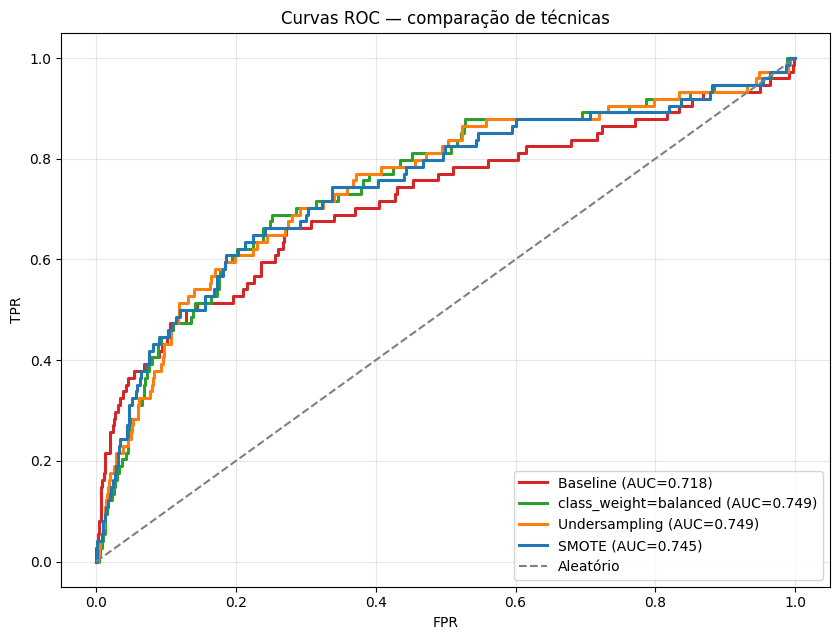

In [ ]:
# Curvas ROC sobrepostas para todas as técnicas
tecnicas_treino = {
    'Baseline': (X_tr, y_tr, {}),
    'class_weight=balanced': (X_tr, y_tr, {'class_weight': 'balanced'}),
    'Undersampling': (Xu, yu, {}),
    'SMOTE': (Xs, ys, {}),
}
plt.figure(figsize=(8.5, 6.5))
cores = ['#d62728', '#2ca02c', '#ff7f0e', '#1f77b4']
for (nome, (Xt, yt, kw)), c in zip(tecnicas_treino.items(), cores):
    m = LogisticRegression(max_iter=1000, **kw).fit(Xt, yt)
    proba = m.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc = roc_auc_score(y_te, proba)
    plt.plot(fpr, tpr, lw=2.2, color=c, label=f'{nome} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Aleatório')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Curvas ROC — comparação de técnicas')
plt.grid(alpha=0.3); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

## Boas práticas e armadilhas

1. **Nunca reamostre o teste.** Aplique SMOTE, undersampling etc. **apenas no treino**. O teste deve refletir a distribuição real.

2. **Use pipelines do `imblearn`** para evitar vazamento em validação cruzada:

   ```python
   from imblearn.pipeline import Pipeline
   from sklearn.preprocessing import StandardScaler
   from sklearn.model_selection import cross_val_score

   pipe = Pipeline([
       ('scaler', StandardScaler()),
       ('smote', SMOTE(random_state=42)),
       ('clf', LogisticRegression(max_iter=1000))
   ])
   scores = cross_val_score(pipe, X, y, scoring='roc_auc', cv=5)
   ```

3. **Prefira PR-AUC à ROC-AUC quando o desbalanceamento for extremo** (< 1%). A ROC pode ser "otimista" porque o eixo FPR tem denominador N (muito grande) e quase não se move. A curva Precision-Recall é mais sensível ao desempenho na classe positiva.

4. **Ajuste o threshold**: após treinar, encontre o threshold ótimo usando a curva ROC (estatística de Youden: $J = TPR - FPR$) ou a curva PR (máximo F1).

5. **Monitore overfitting**: SMOTE pode inflar métricas de treino. Sempre validar em dados intocados.

6. **Não confie só na AUC global**: duas curvas ROC com AUC iguais podem ter comportamentos muito diferentes em regiões de interesse (ex.: FPR < 0.1).



---

# Resumo

| Conceito | Fórmula / Ideia |
|---|---|
| TPR | TP / P — dos positivos reais, quantos acertei |
| FPR | FP / N — dos negativos reais, quantos errei |
| Curva ROC | Todos os (FPR, TPR) variando o threshold |
| AUC | Área sob ROC; prob. de o modelo ranquear um positivo acima de um negativo |
| Desbalanceamento | Accuracy engana; olhe AUC, Recall, F1, PR-AUC |
| SMOTE | Interpola entre vizinhos k-NN da minoritária — cria dados sintéticos |
| Regra de ouro | Reamostre **somente o treino**; use pipeline `imblearn` |


---

# Exercício

Dado o dataset real **[Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)** do Kaggle (~0.17% de fraudes):

1. Treine um baseline e reporte AUC, PR-AUC, Recall e Precision.
2. Aplique 3 técnicas diferentes (class_weight, SMOTE, SMOTE+Tomek).
3. Use validação cruzada estratificada com `imblearn.pipeline.Pipeline`.
4. Ajuste o threshold para maximizar F1 e reporte o ponto ótimo.
5. Justifique qual técnica você recomendaria ao banco considerando o custo operacional de investigar cada alerta.

---

1. [imbalanced-learn](https://imbalanced-learn.org/stable/)

1. [Medium - Sklearn vs Imblearn Pipeline: Preventing Data Leakage in Imbalanced Datasets](https://medium.com/@banjiolaniyan123/sklearn-vs-imblearn-pipeline-preventing-data-leakage-in-imbalanced-datasets-b4272484e985)

1. [Google - ML - Classificação: ROC e AUC](https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc)